In [27]:
import os
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import f1_score, average_precision_score
from tqdm import tqdm

# =============================================================================
# PATHS
# =============================================================================
FEATURES_CSV  = "../Features/EPIC/P01_04_vgg_fused_features.csv"
LABELS_CSV    = "../Labels/EPIC/P01_04_vgg_fused_labeled.csv"
RESULTS_DIR   = "../Results/EPIC/HyperparamTuning"
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# =============================================================================
# HYPERPARAMETER GRID  —  edit values as needed
# =============================================================================
HP_GRID = {
    "lr":          [1e-2, 1e-3, 1e-4],
    "dropout":     [0.2, 0.3, 0.5],
    "batch_size":  [32, 64, 128],
    "window_size": [10, 20, 30],
}
NUM_SEEDS   = 3       # runs per combination  (1 / 3 / 5)
NUM_EPOCHS  = 30

# =============================================================================
# DATA
# =============================================================================
features_df = pd.read_csv(FEATURES_CSV)
labels_df   = pd.read_csv(LABELS_CSV)

X = torch.tensor(
    features_df.drop(columns=["frame_id"]).values, dtype=torch.float32
)
Y = torch.tensor(
    labels_df.drop(columns=["frame_id"]).values, dtype=torch.float32
)

FEATURE_DIM = X.shape[1]
NUM_CLASSES = Y.shape[1]
print(f"Features: {X.shape}  |  Labels: {Y.shape}")

# =============================================================================
# MODEL
# =============================================================================
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# =============================================================================
# WINDOWED DATASET  —  respects window_size HP
# =============================================================================
def make_windowed_dataset(X, Y, window_size):
    """
    Each sample is the mean-pooled feature over a sliding window of frames.
    Label is taken from the last frame in the window.
    """
    Xw, Yw = [], []
    for i in range(window_size - 1, len(X)):
        window = X[i - window_size + 1 : i + 1]   # (window_size, D)
        Xw.append(window.mean(dim=0))              # mean pool → (D,)
        Yw.append(Y[i])
    return torch.stack(Xw), torch.stack(Yw)

# =============================================================================
# TRAIN ONE RUN
# =============================================================================
def train_one_run(lr, dropout, batch_size, window_size, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Windowed features
    Xw, Yw = make_windowed_dataset(X, Y, window_size)

    # 80/20 split
    n_train = int(0.8 * len(Xw))
    n_val   = len(Xw) - n_train
    train_ds, val_ds = random_split(
        TensorDataset(Xw, Yw), [n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    model     = Classifier(FEATURE_DIM, NUM_CLASSES, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {
        "train_loss": [], "val_loss": [],
        "train_f1":   [], "val_f1":   [],
        "val_map":    []
    }

    for epoch in range(NUM_EPOCHS):
        # ── Train ──
        model.train()
        train_losses, all_preds, all_targets = [], [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            all_preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
            all_targets.append(yb.cpu().numpy())

        train_preds   = np.vstack(all_preds)
        train_targets = np.vstack(all_targets)
        train_f1      = f1_score(train_targets, train_preds,
                                  average="macro", zero_division=0)

        # ── Validate ──
        model.eval()
        val_losses, val_preds_list, val_targets_list = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss   = criterion(logits, yb)
                val_losses.append(loss.item())
                val_preds_list.append(
                    (torch.sigmoid(logits) > 0.5).cpu().numpy()
                )
                val_targets_list.append(yb.cpu().numpy())

        val_preds   = np.vstack(val_preds_list)
        val_targets = np.vstack(val_targets_list)
        val_f1      = f1_score(val_targets, val_preds,
                                average="macro", zero_division=0)
        # mAP — per-class AP averaged
        try:
            val_map = average_precision_score(val_targets, val_preds,
                                               average="macro")
        except Exception:
            val_map = 0.0

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(np.mean(val_losses))
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        history["val_map"].append(val_map)

    return history



Using device: cuda
Features: torch.Size([6180, 512])  |  Labels: torch.Size([6180, 29])


In [28]:
# =============================================================================
# RUN FULL GRID SEARCH
# =============================================================================
all_results = []   # one dict per (hp combo + seed)

combos = list(itertools.product(
    HP_GRID["lr"],
    HP_GRID["dropout"],
    HP_GRID["batch_size"],
    HP_GRID["window_size"]
))
print(f"Total combinations: {len(combos)}  ×  {NUM_SEEDS} seeds"
      f"  =  {len(combos) * NUM_SEEDS} runs")

for lr, dropout, batch_size, window_size in tqdm(combos, desc="HP combos"):
    for seed in range(NUM_SEEDS):
        history = train_one_run(lr, dropout, batch_size, window_size, seed)

        all_results.append({
            "lr":          lr,
            "dropout":     dropout,
            "batch_size":  batch_size,
            "window_size": window_size,
            "seed":        seed,
            # Summary metrics (best epoch = highest val_f1)
            "best_val_f1":   max(history["val_f1"]),
            "best_val_map":  max(history["val_map"]),
            "best_val_loss": min(history["val_loss"]),
            "final_train_f1": history["train_f1"][-1],
            "final_val_f1":   history["val_f1"][-1],
            "train_val_gap":  history["train_f1"][-1] - history["val_f1"][-1],
            # Full curves for plotting
            "train_loss_curve": history["train_loss"],
            "val_loss_curve":   history["val_loss"],
            "val_f1_curve":     history["val_f1"],
        })

results_df = pd.DataFrame(all_results)

# Save summary (without curve columns)
summary_cols = [c for c in results_df.columns if "curve" not in c]
results_df[summary_cols].to_csv(
    os.path.join(RESULTS_DIR, "hp_results_summary.csv"), index=False
)
print("Results saved.")

# =============================================================================
# AGGREGATED STATS PER COMBO
# =============================================================================
agg = (
    results_df
    .groupby(["lr", "dropout", "batch_size", "window_size"])
    .agg(
        mean_val_f1  =("best_val_f1",  "mean"),
        std_val_f1   =("best_val_f1",  "std"),
        mean_val_map =("best_val_map", "mean"),
        mean_gap     =("train_val_gap","mean"),
    )
    .reset_index()
)

best_combo = agg.loc[agg["mean_val_f1"].idxmax()]
print("\n🏆 Best Hyperparameter Combination:")
print(best_combo)

Total combinations: 81  ×  3 seeds  =  243 runs


HP combos: 100%|███████████████████████████████████████████████████████████████████████| 81/81 [55:11<00:00, 40.88s/it]

Results saved.

🏆 Best Hyperparameter Combination:
lr                0.001000
dropout           0.300000
batch_size      128.000000
window_size      10.000000
mean_val_f1       0.992576
std_val_f1        0.000387
mean_val_map      0.985641
mean_gap          0.001580
Name: 42, dtype: float64


In [31]:
# # =============================================================================
# # PLOT 1 — BOX + STRIP: Val F1 per HP (one subplot per HP)
# # =============================================================================
# fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# fig.suptitle("Val F1 Distribution per Hyperparameter", fontsize=14, fontweight="bold")

# hp_names  = ["lr", "dropout", "batch_size", "window_size"]
# hp_labels = ["Learning Rate", "Dropout", "Batch Size", "Window Size"]
# colors    = ["Set2", "Set3", "Pastel1", "Pastel2"]

# for ax, hp, label, palette in zip(axes, hp_names, hp_labels, colors):
#     sns.boxplot(data=result_df, x=hp, y="best_val_f1",
#                 ax=ax, palette=palette, width=0.5)
#     sns.stripplot(data=results_df, x=hp, y="best_val_f1",
#                   ax=ax, color="black", size=3, jitter=True, alpha=0.6)
#     ax.set_title(label)
#     ax.set_xlabel(label)
#     ax.set_ylabel("Val F1" if ax == axes[0] else "")
#     ax.tick_params(axis='x', rotation=15)

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR,"plot1_boxplot_per_hp.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
# # plt.savefig(os.path.join(RESULTS_DIR, "plot1_boxplot_per_hp.png"), dpi=150)
# plt.show()

# # =============================================================================
# # PLOT 2 — HEATMAP: LR × Dropout (mean Val F1, averaged over batch/window)
# # =============================================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle("Mean Val F1 Heatmaps", fontsize=14, fontweight="bold")

# # LR × Dropout
# pivot1 = agg.groupby(["lr", "dropout"])["mean_val_f1"].mean().unstack()
# sns.heatmap(pivot1, annot=True, fmt=".3f", cmap="YlGnBu",
#             ax=axes[0], linewidths=0.5)
# axes[0].set_title("LR × Dropout → Val F1")

# # Batch Size × Window Size
# pivot2 = agg.groupby(["batch_size", "window_size"])["mean_val_f1"].mean().unstack()
# sns.heatmap(pivot2, annot=True, fmt=".3f", cmap="YlOrRd",
#             ax=axes[1], linewidths=0.5)
# axes[1].set_title("Batch Size × Window Size → Val F1")

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR,"plot2_heatmaps.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
# # plt.savefig(os.path.join(RESULTS_DIR, "plot2_heatmaps.png"), dpi=150)
# plt.show()

# # =============================================================================
# # PLOT 3 — LOSS CURVES: Top-5 combos by mean Val F1
# # =============================================================================
# top5 = agg.nlargest(5, "mean_val_f1")

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# fig.suptitle("Loss & F1 Curves — Top 5 HP Combos", fontsize=14, fontweight="bold")

# for _, row in top5.iterrows():
#     label = (f"lr={row['lr']} dr={row['dropout']} "
#              f"bs={int(row['batch_size'])} ws={int(row['window_size'])}")
#     # Average curves across seeds for this combo
#     mask = (
#         (results_df["lr"]          == row["lr"])         &
#         (results_df["dropout"]     == row["dropout"])    &
#         (results_df["batch_size"]  == row["batch_size"]) &
#         (results_df["window_size"] == row["window_size"])
#     )
#     subset = results_df[mask]

#     mean_val_loss = np.mean(subset["val_loss_curve"].tolist(), axis=0)
#     mean_val_f1   = np.mean(subset["val_f1_curve"].tolist(),   axis=0)

#     axes[0].plot(mean_val_loss, label=label)
#     axes[1].plot(mean_val_f1,   label=label)

# axes[0].set_title("Val Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
# axes[0].legend(fontsize=7)

# axes[1].set_title("Val F1")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("F1")
# axes[1].legend(fontsize=7)

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR,"plot3_loss_curves_top5.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
# # plt.savefig(os.path.join(RESULTS_DIR, "plot3_loss_curves_top5.png"), dpi=150)
# plt.show()

# # =============================================================================
# # PLOT 4 — OVERFIT GAP: Train−Val F1 gap per Dropout
# # =============================================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle("Overfitting Analysis", fontsize=14, fontweight="bold")

# # Bar plot — gap per dropout
# sns.barplot(data=results_df, x="dropout", y="train_val_gap",
#             hue="lr", palette="coolwarm", ax=axes[0])
# axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
# axes[0].set_title("Train−Val F1 Gap (lower = less overfit)")
# axes[0].set_xlabel("Dropout")
# axes[0].set_ylabel("Gap")
# axes[0].legend(title="LR", fontsize=8)

# # Scatter — Val F1 vs Gap (coloured by dropout)
# sc = axes[1].scatter(
#     results_df["train_val_gap"],
#     results_df["best_val_f1"],
#     c=results_df["dropout"],
#     cmap="viridis", alpha=0.7, s=40
# )
# plt.colorbar(sc, ax=axes[1], label="Dropout")
# axes[1].set_xlabel("Train−Val Gap")
# axes[1].set_ylabel("Best Val F1")
# axes[1].set_title("Val F1 vs Overfit Gap")

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR,"plot4_overfit_analysis.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
# # plt.savefig(os.path.join(RESULTS_DIR, "plot4_overfit_analysis.png"), dpi=150)
# plt.show()

# # =============================================================================
# # PLOT 5 — PARALLEL COORDINATES: All combos coloured by Val F1
# # =============================================================================
# from pandas.plotting import parallel_coordinates

# pc_df = agg.copy()
# pc_df["lr_log"] = np.log10(pc_df["lr"])   # log scale for LR readability
# # Bin mean_val_f1 into High/Mid/Low for colour grouping
# pc_df["f1_tier"] = pd.cut(
#     pc_df["mean_val_f1"],
#     bins=3,
#     labels=["Low", "Mid", "High"]
# )

# fig, ax = plt.subplots(figsize=(14, 6))
# parallel_coordinates(
#     pc_df[["lr_log", "dropout", "batch_size", "window_size", "f1_tier"]],
#     class_column="f1_tier",
#     colormap="RdYlGn",
#     ax=ax, alpha=0.6
# )
# ax.set_title("Parallel Coordinates — HP Combos coloured by Val F1 Tier",
#              fontsize=13, fontweight="bold")
# ax.set_xticklabels(["log10(LR)", "Dropout", "Batch Size", "Window Size"])
# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR,"plot5_parallel_coords.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
# # plt.savefig(os.path.join(RESULTS_DIR, "plot5_parallel_coords.png"), dpi=150)
# plt.show()

In [32]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "="*60)
print("  HYPERPARAMETER TUNING COMPLETE")
print("="*60)
print(f"\n🏆 Best combo:")
print(f"   LR          : {best_combo['lr']}")
print(f"   Dropout     : {best_combo['dropout']}")
print(f"   Batch Size  : {int(best_combo['batch_size'])}")
print(f"   Window Size : {int(best_combo['window_size'])}")
print(f"   Mean Val F1 : {best_combo['mean_val_f1']:.4f} ± {best_combo['std_val_f1']:.4f}")
print(f"   Mean Val mAP: {best_combo['mean_val_map']:.4f}")
print(f"\nAll plots saved to: {RESULTS_DIR}")


  HYPERPARAMETER TUNING COMPLETE

🏆 Best combo:
   LR          : 0.001
   Dropout     : 0.3
   Batch Size  : 128
   Window Size : 10
   Mean Val F1 : 0.9926 ± 0.0004
   Mean Val mAP: 0.9856

All plots saved to: ../Results/EPIC/HyperparamTuning


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_10216\3296501655.py:162: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


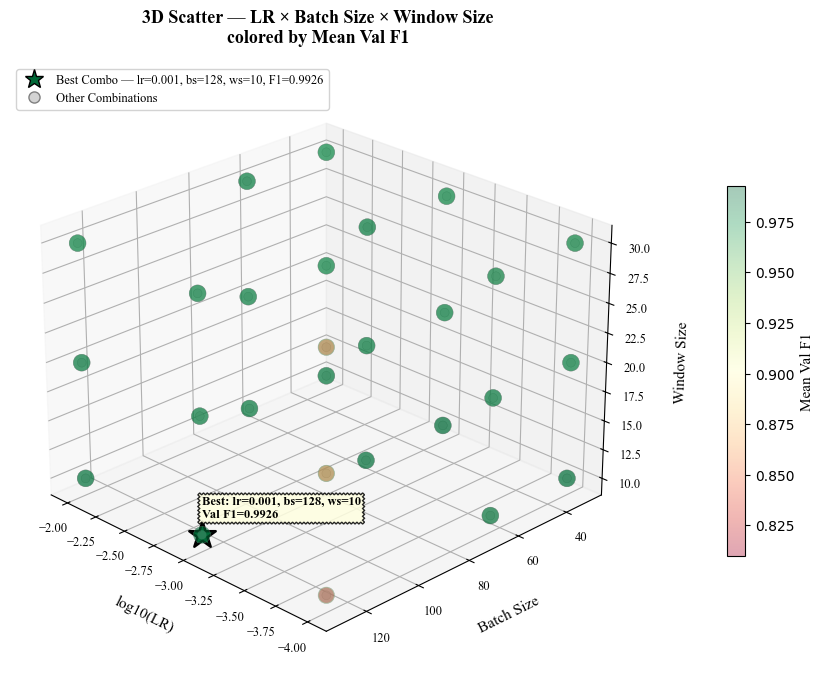

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# =========================
# AGGREGATION
# =========================
agg_plot = agg.copy()

# Find best combination
best_idx = agg_plot["mean_val_f1"].idxmax()
best_row = agg_plot.loc[best_idx]

# =========================
# SPLIT: BEST vs REST
# =========================
mask_best = agg_plot.index == best_idx
mask_rest = ~mask_best

rest_df = agg_plot[mask_rest]
best_df = agg_plot[mask_best]

# =========================
# COLOR NORMALIZATION
# =========================
norm = mcolors.Normalize(vmin=agg_plot["mean_val_f1"].min(),
                         vmax=agg_plot["mean_val_f1"].max())
cmap = plt.cm.RdYlGn

# =========================
# 3D SCATTER PLOT
# =========================
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

# ---- REST points — suppressed (gray, small, transparent) ----
ax.scatter(
    np.log10(rest_df["lr"]),
    rest_df["batch_size"],
    rest_df["window_size"],
    c='lightgray',
    s=40,
    alpha=0.25,
    edgecolors='gray',
    linewidth=0.3,
    zorder=1
)

# ---- ALL points — color encoded but semi-transparent ----
sc = ax.scatter(
    np.log10(rest_df["lr"]),
    rest_df["batch_size"],
    rest_df["window_size"],
    c=rest_df["mean_val_f1"],
    cmap="RdYlGn",
    norm=norm,
    s=rest_df["mean_val_f1"] * 150,
    alpha=0.35,
    edgecolors='gray',
    linewidth=0.3,
    zorder=2
)

# ---- BEST point — fully highlighted ----
ax.scatter(
    np.log10(best_df["lr"]),
    best_df["batch_size"],
    best_df["window_size"],
    c=best_df["mean_val_f1"],
    cmap="RdYlGn",
    norm=norm,
    s=400,
    alpha=1.0,
    edgecolors='black',
    linewidth=1.8,
    marker='*',
    zorder=5
)

# ---- Annotation label for best point ----
best_label = (f"Best: lr={best_row['lr']}, "
              f"bs={int(best_row['batch_size'])}, "
              f"ws={int(best_row['window_size'])}\n"
              f"Val F1={best_row['mean_val_f1']:.4f}")

ax.text(
    np.log10(best_row['lr']),
    best_row['batch_size'],
    best_row['window_size'] + 1.5,   # offset upward
    best_label,
    fontsize=9,
    fontfamily='Times New Roman',
    color='black',
    fontweight='bold',
    bbox=dict(boxstyle='sawtooth,pad=0.3', facecolor='lightyellow',edgecolor='black', alpha=0.85)
)

# =========================
# COLORBAR
# =========================
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label("Mean Val F1", fontsize=11,
               fontfamily='Times New Roman')
cbar.ax.tick_params(labelsize=10)

# =========================
# CUSTOM LEGEND
# =========================
legend_elements = [
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor=cmap(norm(best_row["mean_val_f1"])),
           markeredgecolor='black', markersize=14,
           label=f"Best Combo — lr={best_row['lr']}, "
                 f"bs={int(best_row['batch_size'])}, "
                 f"ws={int(best_row['window_size'])}, "
                 f"F1={best_row['mean_val_f1']:.4f}"),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='lightgray',
           markeredgecolor='gray', markersize=8,
           label='Other Combinations'),
]
ax.legend(handles=legend_elements,
          loc='upper left',
          fontsize=9,
          frameon=True,
          framealpha=0.85,
          prop={'family': 'Times New Roman', 'size': 9})

# =========================
# AXIS LABELS
# =========================
ax.set_xlabel("log10(LR)", fontsize=11,
              fontfamily='Times New Roman', labelpad=10)
ax.set_ylabel("Batch Size", fontsize=11,
              fontfamily='Times New Roman', labelpad=10)
ax.set_zlabel("Window Size", fontsize=11,
              fontfamily='Times New Roman', labelpad=10)

# =========================
# TICK FONT
# =========================
for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontfamily('Times New Roman')
    label.set_fontsize(9)

# =========================
# TITLE
# =========================
ax.set_title("3D Scatter — LR × Batch Size × Window Size\ncolored by Mean Val F1",
             fontsize=13, fontweight='bold',
             fontfamily='Times New Roman', pad=15)

# =========================
# VIEWING ANGLE
# =========================
ax.view_init(elev=25, azim=135)

ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "plot_3d_scatter.eps"),
#             format='eps', dpi=1000, bbox_inches='tight')
plt.show()

C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_10216\3513393249.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


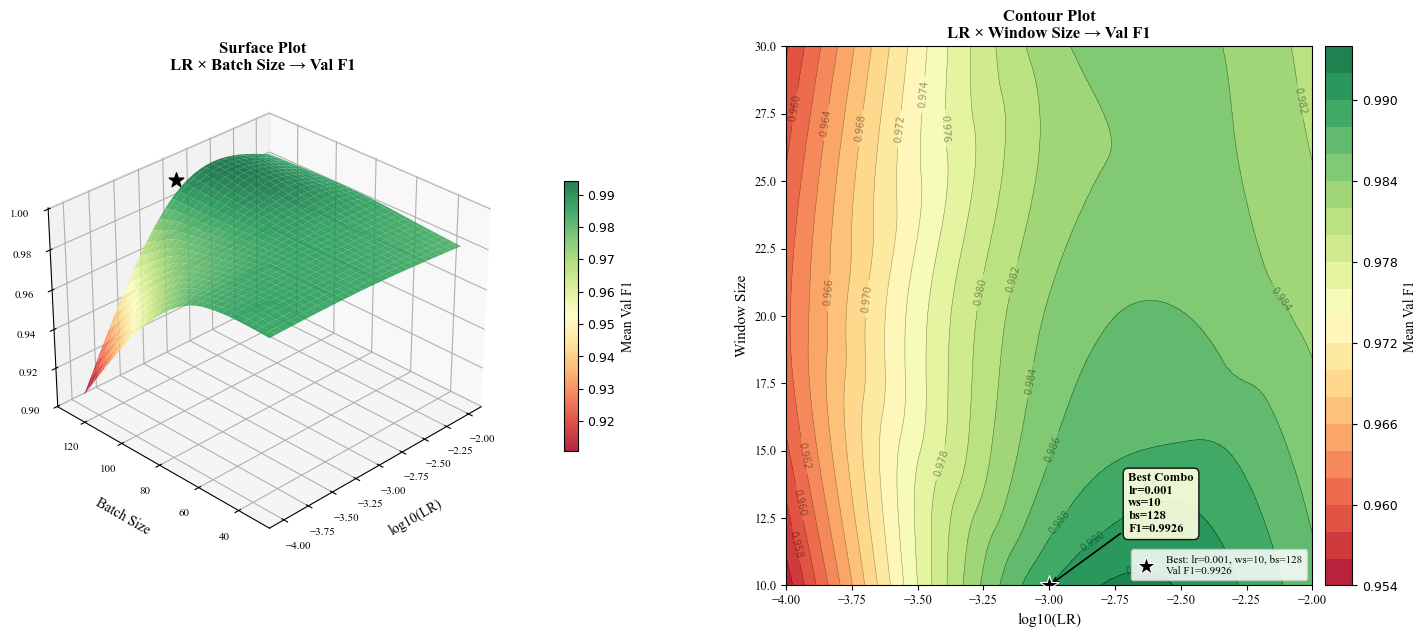

In [37]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from scipy.interpolate import griddata
# import matplotlib.colors as mcolors
# from matplotlib.lines import Line2D

# # =========================
# # AGGREGATION
# # =========================
# agg_plot = agg.copy()
# agg_plot["lr_log"] = np.log10(agg_plot["lr"])

# # Find best combination
# best_idx = agg_plot["mean_val_f1"].idxmax()
# best_row = agg_plot.loc[best_idx]

# # =========================
# # GRID INTERPOLATION
# # =========================
# x = agg_plot["lr_log"].values
# y = agg_plot["batch_size"].values
# z = agg_plot["window_size"].values
# f = agg_plot["mean_val_f1"].values

# # Create meshgrid for surface
# xi = np.linspace(x.min(), x.max(), 60)
# yi = np.linspace(y.min(), y.max(), 60)
# Xi, Yi = np.meshgrid(xi, yi)

# # =========================
# # SUBPLOTS: Surface + Contour
# # =========================
# fig = plt.figure(figsize=(18, 7))

# # -----------------------------------------------
# # LEFT — 3D Surface Plot (LR × Batch Size → F1)
# # averaged over window_size
# # -----------------------------------------------
# ax1 = fig.add_subplot(121, projection='3d')

# # Average F1 over window_size for each lr × batch_size combo
# pivot_surf = agg_plot.groupby(["lr_log", "batch_size"])["mean_val_f1"].mean().reset_index()
# xs = pivot_surf["lr_log"].values
# ys = pivot_surf["batch_size"].values
# fs = pivot_surf["mean_val_f1"].values

# Zi_surf = griddata((xs, ys), fs, (Xi, Yi), method='cubic')

# surf = ax1.plot_surface(
#     Xi, Yi, Zi_surf,
#     cmap='RdYlGn',
#     alpha=0.85,
#     edgecolor='none',
#     antialiased=True
# )

# # ---- Best point on surface ----
# ax1.scatter(
#     np.log10(best_row["lr"]),
#     best_row["batch_size"],
#     best_row["mean_val_f1"],
#     color='black', s=120,
#     marker='*', zorder=5,
#     label='Best Combo'
# )

# # ---- Colorbar ----
# cbar1 = fig.colorbar(surf, ax=ax1, pad=0.1, shrink=0.5)
# cbar1.set_label("Mean Val F1", fontsize=10,
#                 fontfamily='Times New Roman')
# cbar1.ax.tick_params(labelsize=9)

# ax1.set_xlabel("log10(LR)", fontsize=10,
#                fontfamily='Times New Roman', labelpad=8)
# ax1.set_ylabel("Batch Size", fontsize=10,
#                fontfamily='Times New Roman', labelpad=8)
# ax1.set_zlabel("Mean Val F1", fontsize=10,
#                fontfamily='Times New Roman', labelpad=8)
# ax1.set_title("Surface Plot\nLR × Batch Size → Val F1",
#               fontsize=12, fontweight='bold',
#               fontfamily='Times New Roman')
# ax1.view_init(elev=30, azim=225)

# for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax1.get_zticklabels():
#     label.set_fontfamily('Times New Roman')
#     label.set_fontsize(8)

# # -----------------------------------------------
# # RIGHT — 2D Contour Plot (LR × Window Size → F1)
# # averaged over batch_size
# # -----------------------------------------------
# ax2 = fig.add_subplot(122)

# pivot_cont = agg_plot.groupby(["lr_log", "window_size"])["mean_val_f1"].mean().reset_index()
# xc = pivot_cont["lr_log"].values
# yc = pivot_cont["window_size"].values
# fc = pivot_cont["mean_val_f1"].values

# xi2 = np.linspace(xc.min(), xc.max(), 80)
# yi2 = np.linspace(yc.min(), yc.max(), 80)
# Xi2, Yi2 = np.meshgrid(xi2, yi2)
# Zi2 = griddata((xc, yc), fc, (Xi2, Yi2), method='cubic')

# # ---- Filled contour ----
# cf = ax2.contourf(Xi2, Yi2, Zi2,
#                   levels=20,
#                   cmap='RdYlGn',
#                   alpha=0.9)

# # ---- Contour lines ----
# cl = ax2.contour(Xi2, Yi2, Zi2,
#                  levels=20,
#                  colors='black',
#                  linewidths=0.4,
#                  alpha=0.4)
# ax2.clabel(cl, inline=True, fontsize=7, fmt="%.3f")

# # ---- Best point on contour ----
# ax2.scatter(
#     np.log10(best_row["lr"]),
#     best_row["window_size"],
#     color='black', s=200,
#     marker='*', zorder=5,
#     edgecolors='white', linewidth=0.8,
#     label=f"Best: lr={best_row['lr']}, "
#           f"ws={int(best_row['window_size'])}, "
#           f"bs={int(best_row['batch_size'])}\n"
#           f"Val F1={best_row['mean_val_f1']:.4f}"
# )

# # ---- Annotation box ----
# ax2.annotate(
#     f"Best Combo\nlr={best_row['lr']}\n"
#     f"ws={int(best_row['window_size'])}\n"
#     f"bs={int(best_row['batch_size'])}\n"
#     f"F1={best_row['mean_val_f1']:.4f}",
#     xy=(np.log10(best_row["lr"]), best_row["window_size"]),
#     xytext=(np.log10(best_row["lr"]) + 0.3,
#             best_row["window_size"] + 2),
#     fontsize=9,
#     fontfamily='Times New Roman',
#     fontweight='bold',
#     arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
#     bbox=dict(boxstyle='round,pad=0.4',
#               facecolor='lightyellow',
#               edgecolor='black', alpha=0.9)
# )

# # ---- Colorbar ----
# cbar2 = fig.colorbar(cf, ax=ax2, pad=0.02)
# cbar2.set_label("Mean Val F1", fontsize=10,
#                 fontfamily='Times New Roman')
# cbar2.ax.tick_params(labelsize=9)

# ax2.set_xlabel("log10(LR)", fontsize=11,
#                fontfamily='Times New Roman')
# ax2.set_ylabel("Window Size", fontsize=11,
#                fontfamily='Times New Roman')
# ax2.set_title("Contour Plot\nLR × Window Size → Val F1",
#               fontsize=12, fontweight='bold',
#               fontfamily='Times New Roman')

# for label in ax2.get_xticklabels() + ax2.get_yticklabels():
#     label.set_fontfamily('Times New Roman')
#     label.set_fontsize(9)

# ax2.legend(loc='lower right', fontsize=8,
#            frameon=True, framealpha=0.85,
#            prop={'family': 'Times New Roman', 'size': 8})

# ax2.grid(False)

# plt.tight_layout()
# # plt.savefig(os.path.join(RESULTS_DIR, "plot_surface_contour.eps"),
# #             format='eps', dpi=1000, bbox_inches='tight')
# plt.show()

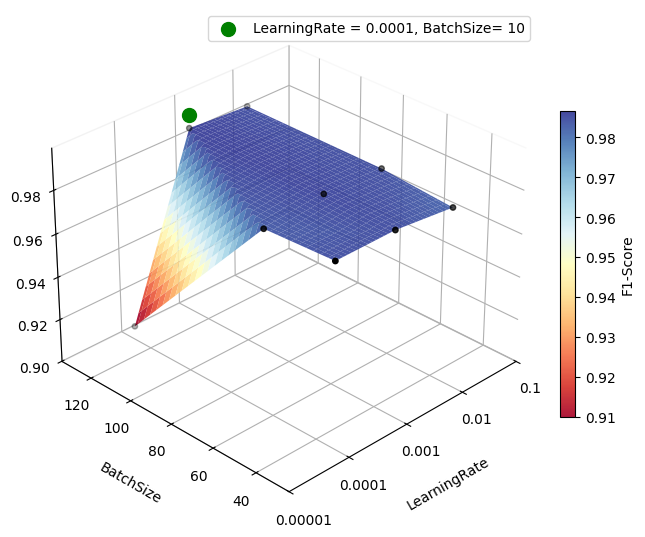

In [135]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import griddata

# # =========================
# # AGGREGATION
# # =========================
# agg_plot = agg.copy()
# agg_plot["lr_log"] = np.log10(agg_plot["lr"])

# # Best combination
# best_idx = agg_plot["mean_val_f1"].idxmax()
# best_row = agg_plot.loc[best_idx]

# # =========================
# # SURFACE DATA PREP
# # =========================
# pivot_surf = agg_plot.groupby(
#     ["lr_log", "batch_size"]
# )["mean_val_f1"].mean().reset_index()

# x = pivot_surf["lr_log"].values
# y = pivot_surf["batch_size"].values
# z = pivot_surf["mean_val_f1"].values

# # Grid
# xi = np.linspace(x.min(), x.max(), 30)
# yi = np.linspace(y.min(), y.max(), 30)
# Xi, Yi = np.meshgrid(xi, yi)

# Zi = griddata((x, y), z, (Xi, Yi), method='cubic')

# # =========================
# # PLOT (ONLY SURFACE)
# # =========================
# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111, projection='3d')

# surf = ax.plot_surface(
#     Xi, Yi, Zi,
#     cmap='RdYlGn',
#     alpha=0.8,
#     edgecolor='none',
#     antialiased=True
# )

# # Best point
# ax.scatter(
#     np.log10(best_row["lr"]),
#     best_row["batch_size"],
#     best_row["mean_val_f1"],
#     color='red',
#     s=100,
#     marker='o'
# )

# # Colorbar
# cbar = fig.colorbar(surf, ax=ax, pad=0.01, shrink=0.6)
# cbar.set_label("F1-Score")

# # Labels
# ax.set_xlabel("Learning Rate")
# ax.set_ylabel("Batch Size")
# ax.set_zlabel("F1-Score")

# # ax.set_title("Surface Plot: LR × Batch Size → Val F1")

# ax.legend()
# ax.view_init(elev=30, azim=225)

# plt.tight_layout()
# plt.show()



import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================
# DATA (KEEP LOG INTERNALLY)
# =========================
agg_plot = agg.copy()
agg_plot["lr_log"] = np.log10(agg_plot["lr"])

best_idx = agg_plot["mean_val_f1"].idxmax()
best_row = agg_plot.loc[best_idx]

pivot_surf = agg_plot.groupby(
    ["lr_log", "batch_size"]
)["mean_val_f1"].mean().reset_index()

x = pivot_surf["lr_log"].values   # LOG values
y = pivot_surf["batch_size"].values
z = pivot_surf["mean_val_f1"].values

# =========================
# GRID
# =========================
xi = np.linspace(x.min(), x.max(), 60)
yi = np.linspace(y.min(), y.max(), 60)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), z, (Xi, Yi), method='linear')

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Clean background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Surface
surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap='RdYlBu',
    edgecolor='none',
    alpha=0.90
)

# Points
ax.scatter(x, y, z, color='black', s=15)

# Best point
ax.scatter(
    np.log10(best_row["lr"]),
    best_row["batch_size"],
    best_row["mean_val_f1"],
    color='green',
    s=100,
    marker='o',
    label='LearningRate = 0.0001, BatchSize= 10'
)

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.03)
cbar.set_label("F1-Score")

# Labels
ax.set_xlabel("LearningRate", labelpad=12)
ax.set_ylabel("BatchSize", labelpad=12)
ax.set_zlabel("F1-Score", labelpad=10)

# =========================
# 🔥 KEY FIX: Show original LR values
# =========================
log_ticks = np.log10([1e-1, 1e-2, 1e-3, 1e-4, 1e-5])
labels = ["0.1", "0.01", "0.001", "0.0001", "0.00001"]

ax.set_xticks(log_ticks)
ax.set_xticklabels(labels)

# View
ax.view_init(elev=30, azim=225)

# Layout
fig.subplots_adjust(left=0.15, right=0.9, bottom=0.1, top=0.95)

ax.legend()

plt.show()